# Chronos-2 时序预测——零售需求（含协变量）

使用 Amazon Chronos-2 预测门店下一季度（13周）的周销售额，以 **Open**、**Promo**、**SchoolHoliday**、**StateHoliday** 作为已知未来协变量，并与不含协变量的基线对比。

数据：AutoGluon retail_sales（Rossmann 门店销售，周频，门店 ID = "1"）

预测步长：13 周

In [8]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cpu")

In [9]:
TARGET            = 'Sales'
ID_COL            = 'id'
TS_COL            = 'timestamp'
TIMESERIES_ID     = '1'
PREDICTION_LENGTH = 13
SHOW_HISTORY      = 104

sales_context_df = pd.read_parquet(
    'https://autogluon.s3.amazonaws.com/datasets/timeseries/retail_sales/train.parquet',
    engine='fastparquet'
)
sales_context_df[TS_COL] = pd.to_datetime(sales_context_df[TS_COL])

sales_test_df = pd.read_parquet(
    'https://autogluon.s3.amazonaws.com/datasets/timeseries/retail_sales/test.parquet',
    engine='fastparquet'
)
sales_test_df[TS_COL] = pd.to_datetime(sales_test_df[TS_COL])

# future_df 仅保留协变量（去掉目标列 Sales）
sales_future_df = sales_test_df.drop(columns=TARGET)

print('训练数据:', sales_context_df.shape, '| 列:', list(sales_context_df.columns))
print(f'时间范围: {sales_context_df[TS_COL].min().date()} ~ {sales_context_df[TS_COL].max().date()}')
print('预测期:',  sales_test_df[TS_COL].min().date(), '~', sales_test_df[TS_COL].max().date())
sales_context_df.head(3)

训练数据: (133800, 8) | 列: ['id', 'timestamp', 'Sales', 'Open', 'Promo', 'SchoolHoliday', 'StateHoliday', 'Customers']
时间范围: 2013-01-13 ~ 2015-04-26
预测期: 2015-05-03 ~ 2015-07-26


,id,timestamp,Sales,Open,Promo,SchoolHoliday,StateHoliday,Customers
0,1,2013-01-13,32952.0,0.857143,0.714286,5.0,0.0,3918.0
1,1,2013-01-20,25978.0,0.857143,0.000000,0.0,0.0,3417.0
2,1,2013-01-27,33071.0,0.857143,0.714286,0.0,0.0,3862.0


In [10]:
# 使用协变量预测
sales_pred_df = pipeline.predict_df(
    sales_context_df,
    future_df=sales_future_df,
    prediction_length=PREDICTION_LENGTH,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=ID_COL,
    timestamp_column=TS_COL,
    target=TARGET,
)
print('预测结果维度:', sales_pred_df.shape)
sales_pred_df.head()

预测结果维度: (14495, 7)


,id,timestamp,target_name,predictions,0.1,0.5,0.9
0,1,2015-05-03,Sales,28939.392578,25214.275391,28939.392578,32411.095703
1,1,2015-05-10,Sales,25541.919922,21921.328125,25541.919922,29191.929688
2,1,2015-05-17,Sales,23640.238281,20500.339844,23640.238281,26884.664062
3,1,2015-05-24,Sales,26778.261719,23318.355469,26778.261719,30162.820312
4,1,2015-05-31,Sales,22679.359375,19722.279297,22679.359375,25990.039062


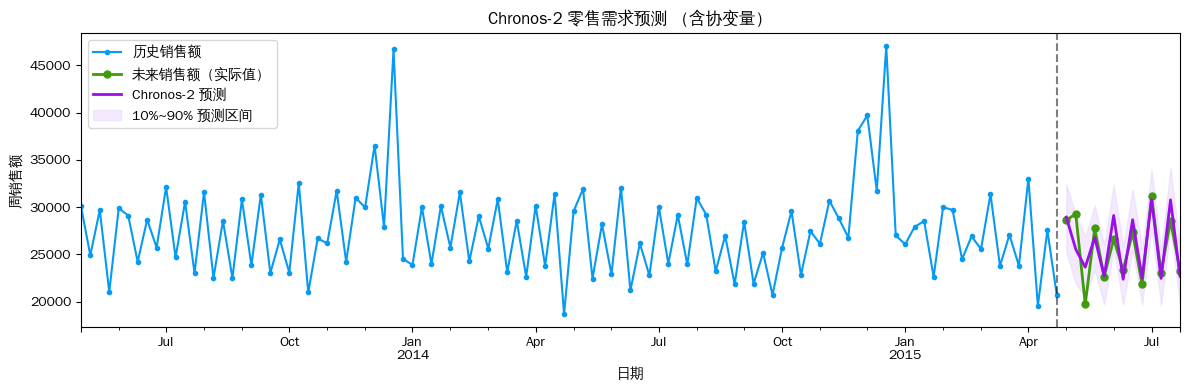

In [11]:
def plot_chronos_retail(context_df, pred_df, test_df, timeseries_id, title_suffix=''):
    ts_ctx  = context_df.query(f"{ID_COL} == @timeseries_id").set_index(TS_COL)[TARGET]
    ts_pred = pred_df.query(f"{ID_COL} == @timeseries_id and target_name == @TARGET").set_index(TS_COL)[['0.1', 'predictions', '0.9']]
    ts_gt   = test_df.query(f"{ID_COL} == @timeseries_id").set_index(TS_COL)[TARGET]

    start_idx = max(0, len(ts_ctx) - SHOW_HISTORY)
    plot_from  = ts_ctx.index[start_idx]
    ts_ctx     = ts_ctx[ts_ctx.index >= plot_from]

    fig, ax = plt.subplots(figsize=(12, 4))
    ts_ctx.plot(ax=ax, label='历史销售额', color='xkcd:azure', marker='o', markersize=3)
    ts_gt.plot(ax=ax,  label='未来销售额（实际值）', color='xkcd:grass green', marker='o', markersize=5, linewidth=2)
    ts_pred['predictions'].plot(ax=ax, label='Chronos-2 预测', color='xkcd:violet', linewidth=2)
    ax.fill_between(ts_pred.index, ts_pred['0.1'], ts_pred['0.9'],
                    alpha=0.35, label='10%~90% 预测区间', color='xkcd:light lavender')
    ax.axvline(x=context_df.query(f"{ID_COL} == @timeseries_id")[TS_COL].max(),
               color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'Chronos-2 零售需求预测 {title_suffix}')
    ax.set_xlabel('日期')
    ax.set_ylabel('周销售额')
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

plot_chronos_retail(sales_context_df, sales_pred_df, sales_test_df,
                    TIMESERIES_ID, title_suffix='（含协变量）')

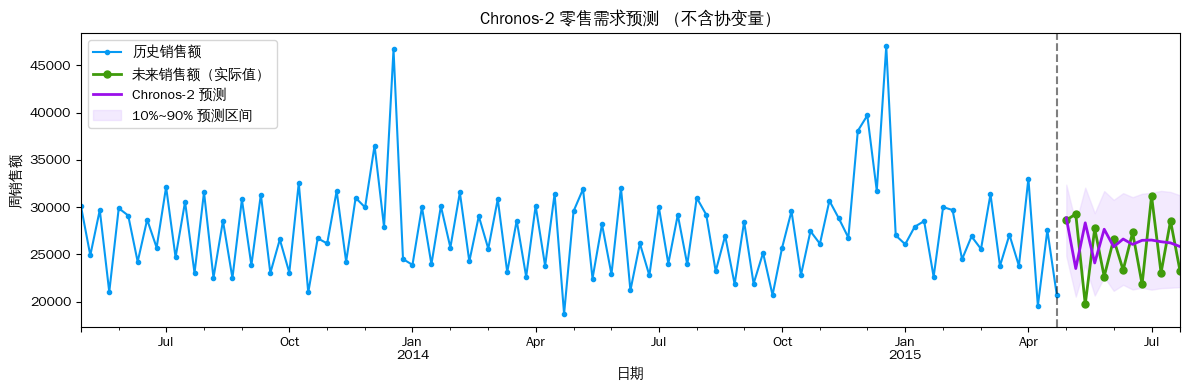

In [12]:
# 对比：不含协变量的基线
sales_pred_no_cov = pipeline.predict_df(
    sales_context_df[[ID_COL, TS_COL, TARGET]],
    future_df=None,
    prediction_length=PREDICTION_LENGTH,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=ID_COL,
    timestamp_column=TS_COL,
    target=TARGET,
)

plot_chronos_retail(sales_context_df, sales_pred_no_cov, sales_test_df,
                    TIMESERIES_ID, title_suffix='（不含协变量）')

In [13]:
# 误差指标对比
gt = (sales_test_df.query(f"{ID_COL} == @TIMESERIES_ID")
      .sort_values(TS_COL)[TARGET].values)

def calc_metrics(pred_df, timeseries_id, label):
    y_pred = pred_df.query(f"{ID_COL} == @timeseries_id and target_name == @TARGET").sort_values(TS_COL)['predictions'].values
    mae  = np.mean(np.abs(gt - y_pred))
    rmse = np.sqrt(np.mean((gt - y_pred) ** 2))
    mape = np.mean(np.abs((gt - y_pred) / gt)) * 100
    print(f'{label}  MAE={mae:.1f}  RMSE={rmse:.1f}  MAPE={mape:.2f}%')

print('─' * 55)
calc_metrics(sales_pred_df,     TIMESERIES_ID, 'Chronos-2 含协变量:  ')
calc_metrics(sales_pred_no_cov, TIMESERIES_ID, 'Chronos-2 不含协变量:')
print('─' * 55)

───────────────────────────────────────────────────────
Chronos-2 含协变量:    MAE=1403.2  RMSE=1876.0  MAPE=5.62%
Chronos-2 不含协变量:  MAE=3552.2  RMSE=4167.2  MAPE=14.71%
───────────────────────────────────────────────────────


## 微调
Chronos-2 支持在您自己的数据上进行微调。您可以微调模型的所有权重（全量微调），也可以微调低秩适配器（LoRA），这可以显著减少可训练参数的数量。

### 微调 API
fit 方法接受以下参数：

- inputs：用于微调的时间序列（与 predict_quantiles 格式相同）
- finetune_mode：“full” 或 “lora”
- lora_config：LoraConfig，当 finetune_mode="lora" 时使用
- prediction_length：微调的预测时间长度
- validation_inputs：可选的验证数据（格式与 inputs 相同）
- learning_rate：优化器学习率（默认：1e-6，我们建议对于 LoRA 使用较高的学习率，例如 1e-5）
- num_steps：训练步骤数（默认：1000）
- batch_size：训练批量大小（默认：256）

返回一个带有微调模型的新管道。

In [14]:
# 使用零售销售数据集准备微调数据
known_covariates = ["Open", "Promo", "SchoolHoliday", "StateHoliday"]
past_covariates = ["Customers"]

train_inputs = []
for item_id, group in sales_context_df.groupby("id"):
    train_inputs.append({
        "target": group[TARGET].values,
        "past_covariates": {col: group[col].values for col in past_covariates + known_covariates},
        # 在训练期间不会使用协变量的未来值。
        # 但是，我们需要包含它们的名称以表明这些列在预测时将可用
        "future_covariates": {col: None for col in known_covariates},
    })

In [15]:
# 使用全量微调
finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=13,
    num_steps=1000,
    learning_rate=1e-5,
    batch_size=32,
    logging_steps=100,
)

/home/zf/code/docs/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
100,0.662000
200,0.537300
300,0.513700
400,0.463300
500,0.460100
600,0.523700
700,0.458800
800,0.430700
900,0.440700
1000,0.498400


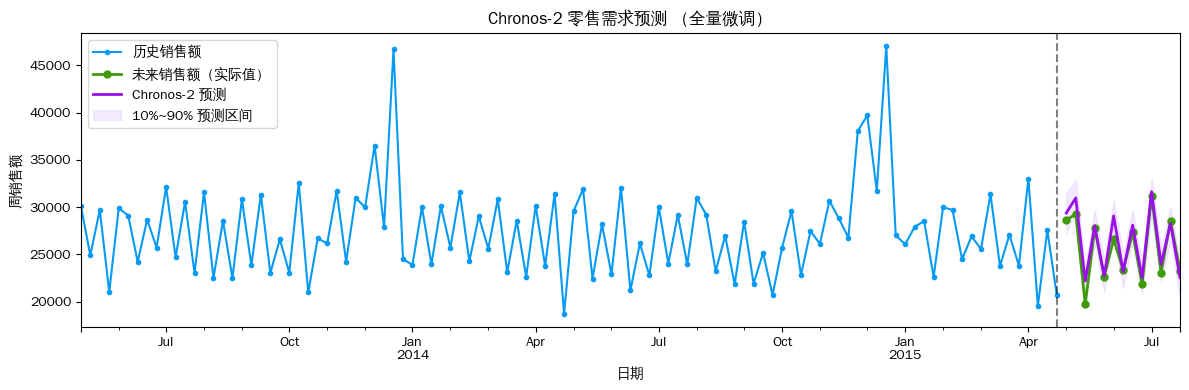

───────────────────────────────────────────────────────
Chronos-2 全量微调:    MAE=905.2  RMSE=1193.7  MAPE=3.68%
───────────────────────────────────────────────────────


In [16]:
# 使用微调模型进行预测
finetuned_pred_df = finetuned_pipeline.predict_df(
    sales_context_df,
    future_df=sales_future_df,
    prediction_length=13,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=ID_COL,
    timestamp_column=TS_COL,
    target=TARGET,
)

plot_chronos_retail(
    sales_context_df,
    finetuned_pred_df,
    sales_test_df,
    timeseries_id=TIMESERIES_ID,
    title_suffix="（全量微调）",
)

print('─' * 55)
calc_metrics(finetuned_pred_df, TIMESERIES_ID, 'Chronos-2 全量微调:  ')
print('─' * 55)

In [17]:
# 使用LoRA微调模型
lora_finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=13,
    num_steps=1000,
    learning_rate=1e-4,
    batch_size=32,
    logging_steps=100,
    finetune_mode="lora",
)

/home/zf/code/docs/.venv/lib/python3.10/site-packages/chronos/chronos2/pipeline.py:180: UserWarning: `peft` is required for `finetune_mode='lora'`. Please install it with `pip install peft`. Falling back to `finetune_mode='full'`.
  warnings.warn(
Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
100,0.749900
200,0.649700
300,0.598100
400,0.532700
500,0.515100
600,0.569400
700,0.496200
800,0.449700
900,0.451000
1000,0.492700


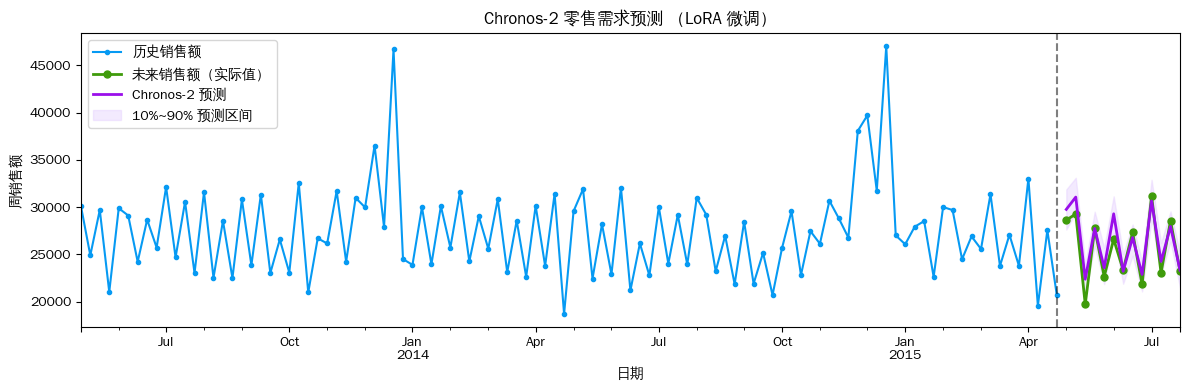

───────────────────────────────────────────────────────
Chronos-2 LoRA 微调:   MAE=1024.7  RMSE=1335.1  MAPE=4.19%
───────────────────────────────────────────────────────


In [18]:
# 使用LoRA微调模型进行预测
lora_finetuned_pred_df = lora_finetuned_pipeline.predict_df(
    sales_context_df,
    future_df=sales_future_df,
    prediction_length=13,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=ID_COL,
    timestamp_column=TS_COL,
    target=TARGET,
)

plot_chronos_retail(
    sales_context_df,
    lora_finetuned_pred_df,
    sales_test_df,
    timeseries_id=TIMESERIES_ID,
    title_suffix="（LoRA 微调）",
)

print('─' * 55)
calc_metrics(lora_finetuned_pred_df, TIMESERIES_ID, 'Chronos-2 LoRA 微调: ')
print('─' * 55)